# 02 — Class Balancing with CTGAN

CICIDS2017 is wildly imbalanced (BENIGN dominates ~80%, several attacks have
< 2k rows). We balance in two stages:

1. **Undersample** BENIGN to a manageable size.
2. **CTGAN-oversample** every remaining minority class to a target size.

CTGAN models the joint distribution of tabular features per class, which is
better suited than SMOTE to the heavy-tailed numeric features in CICIDS.


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src import config as cfg
from src.gan_balancer import undersample_benign, gan_oversample
sns.set_theme(style="whitegrid")


## 1. Load the cleaned training split

In [2]:
train = pd.read_csv(cfg.PROCESSED_DIR / "train.csv")
print("Loaded:", train.shape)
print(train[cfg.LABEL_COL].value_counts())


Loaded: (1979465, 79)
Label
BENIGN                      1711762
DoS Hulk                     230124
DoS GoldenEye                 10293
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Web Attack  Brute Force       1507
Web Attack  XSS                652
Name: count, dtype: int64


## 2. Before — class distribution

In [3]:
before = train[cfg.LABEL_COL].value_counts()
fig = px.bar(x=before.index, y=before.values, log_y=True,
             title="Before balancing (log scale)",
             labels={"x":"class","y":"count"})
fig.show()


## 3. Stage 1 — undersample BENIGN

In [4]:
train_under = undersample_benign(train, target_size=cfg.UNDERSAMPLE_BENIGN_TO)
print(train_under[cfg.LABEL_COL].value_counts())


Label
DoS Hulk                    230124
BENIGN                      120000
DoS GoldenEye                10293
FTP-Patator                   7935
SSH-Patator                   5897
DoS slowloris                 5796
DoS Slowhttptest              5499
Web Attack  Brute Force      1507
Web Attack  XSS               652
Name: count, dtype: int64


## 4. Stage 2 — CTGAN oversample minorities

> Each class with `< target_per_class` rows gets its own CTGAN. Training
> CTGAN is GPU-friendly but CPU-runnable; expect a few minutes per minority class.


In [5]:
balanced = gan_oversample(
    train_under,
    target_per_class=cfg.GAN_TARGET_PER_CLASS,
    epochs=150,
    skip_classes=("BENIGN",),
)
print("After GAN:")
print(balanced[cfg.LABEL_COL].value_counts())


[skip] DoS Hulk: 230,124 rows (no synthesis)
[skip] BENIGN: 120,000 rows (no synthesis)


2026-05-09 06:03:59,842 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Protocol. Extra column not created.
2026-05-09 06:04:02,573 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Flow Duration. Extra column not created.
2026-05-09 06:04:03,789 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Fwd Packets. Extra column not created.
2026-05-09 06:04:04,759 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Backward Packets. Extra column not created.
2026-05-09 06:04:04,905 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Fwd Packets. Extra column not created.
2026-05-09 06:04:06,077 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Bwd Packets. Extra column not created.
2026-05-09 06:04:06,295 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Fwd 

[gan]  DoS GoldenEye: 10,293 -> 50,000 (+39,707)


2026-05-09 06:17:09,290 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Protocol. Extra column not created.
2026-05-09 06:17:09,853 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Flow Duration. Extra column not created.
2026-05-09 06:17:10,637 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Fwd Packets. Extra column not created.
2026-05-09 06:17:10,752 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Backward Packets. Extra column not created.
2026-05-09 06:17:11,065 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Fwd Packets. Extra column not created.
2026-05-09 06:17:11,940 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Bwd Packets. Extra column not created.
2026-05-09 06:17:12,084 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Fwd 

[gan]  FTP-Patator: 7,935 -> 50,000 (+42,065)


...

[gan]  DoS Slowhttptest: 5,499 -> 50,000 (+44,501)


2026-05-09 06:40:39,823 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Fwd Packets. Extra column not created.
2026-05-09 06:40:39,899 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Backward Packets. Extra column not created.
2026-05-09 06:40:39,947 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Fwd Packets. Extra column not created.
2026-05-09 06:40:40,026 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Bwd Packets. Extra column not created.
2026-05-09 06:40:40,086 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Fwd Packet Length Max. Extra column not created.
2026-05-09 06:40:40,122 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Fwd Packet Length Min. Extra column not created.
2026-05-09 06:40:40,152 [INFO] rdt.transformers.null: Guidance: There are no missing 

[gan]  Web Attack  Brute Force: 1,507 -> 50,000 (+48,493)


2026-05-09 06:41:58,133 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Flow Duration. Extra column not created.
2026-05-09 06:41:58,207 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Fwd Packets. Extra column not created.
2026-05-09 06:41:58,266 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Backward Packets. Extra column not created.
2026-05-09 06:41:58,345 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Fwd Packets. Extra column not created.
2026-05-09 06:41:58,434 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Total Length of Bwd Packets. Extra column not created.
2026-05-09 06:41:58,498 [INFO] rdt.transformers.null: Guidance: There are no missing values in column Fwd Packet Length Max. Extra column not created.
2026-05-09 06:41:58,535 [INFO] rdt.transformers.null: Guidance: There are no missing values i

[gan]  Web Attack  XSS: 652 -> 50,000 (+49,348)
After GAN:
Label
DoS Hulk                    230124
BENIGN                      120000
Web Attack  XSS             50000
DoS Slowhttptest             50000
SSH-Patator                  50000
Web Attack  Brute Force     50000
DoS GoldenEye                50000
DoS slowloris                50000
FTP-Patator                  50000
Name: count, dtype: int64


## 5. After — class distribution

C:\Users\diable\AppData\Local\Temp\ipykernel_14236\3007025321.py:11: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  plt.tight_layout()
d:\smart_ids\ids_pfa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


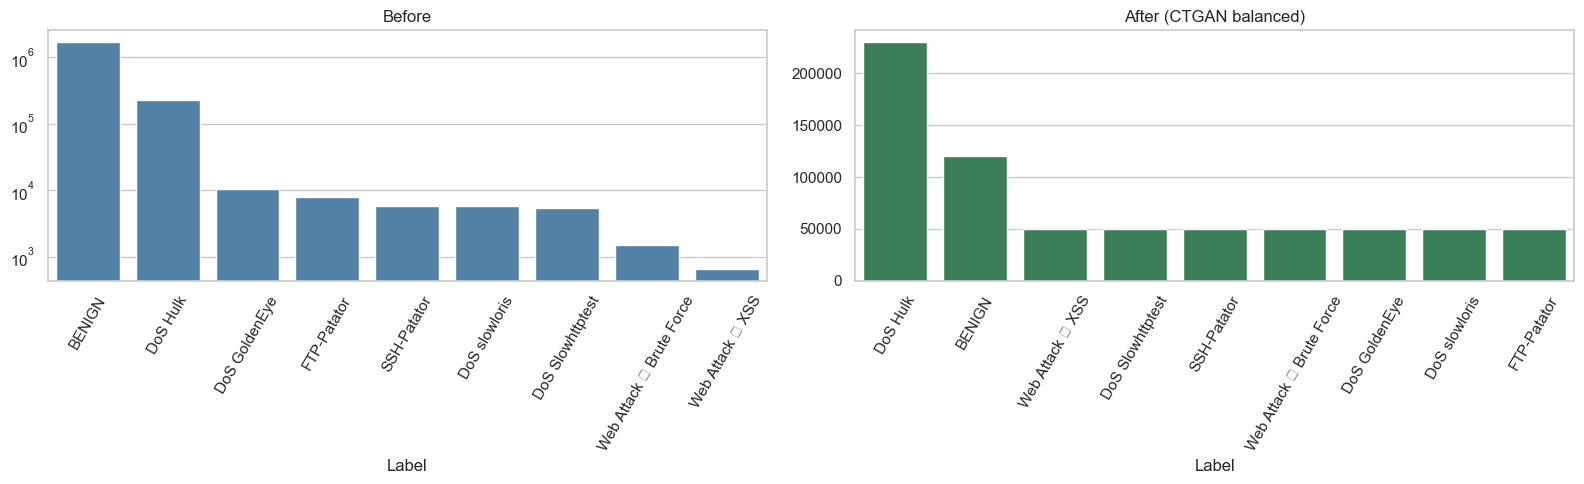

In [6]:
after = balanced[cfg.LABEL_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=before.index, y=before.values, ax=axes[0], color="steelblue")
axes[0].set_yscale("log"); axes[0].set_title("Before")
axes[0].tick_params(axis="x", rotation=60)

sns.barplot(x=after.index, y=after.values, ax=axes[1], color="seagreen")
axes[1].set_title("After (CTGAN balanced)")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


## 6. Sanity check — synthetic vs real distribution for a few features

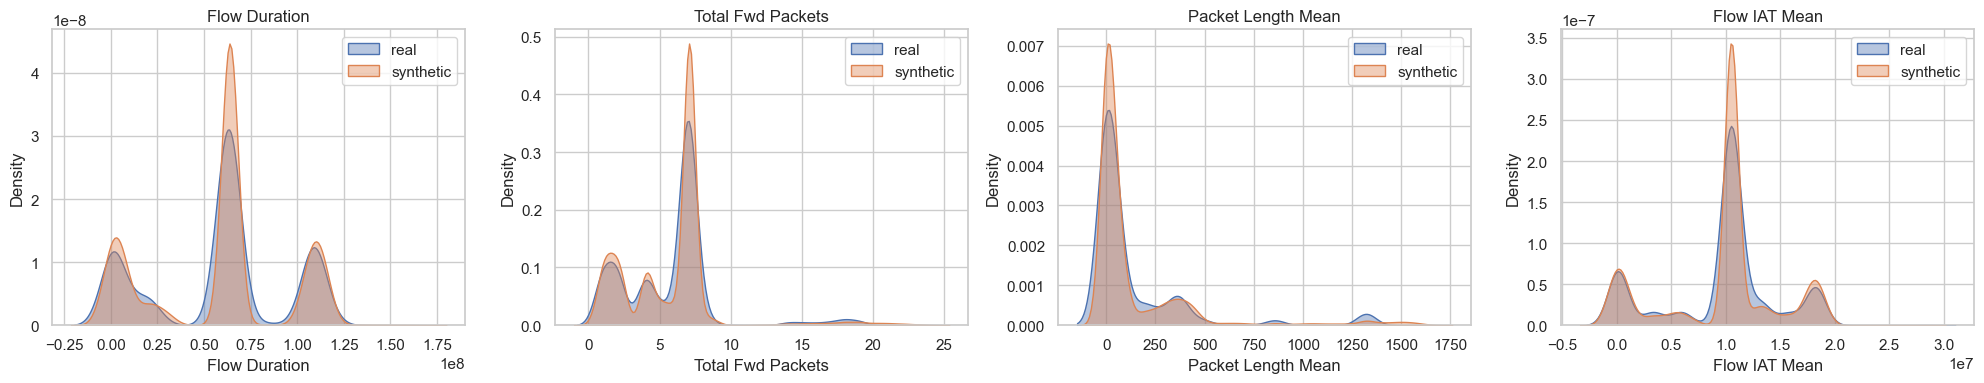

In [7]:
def compare_dist(real, synth, feature, ax):
    sns.kdeplot(real[feature],  ax=ax, label="real",      fill=True, alpha=0.4)
    sns.kdeplot(synth[feature], ax=ax, label="synthetic", fill=True, alpha=0.4)
    ax.set_title(feature); ax.legend()

minority = "DoS Slowhttptest"
real_min  = train[train[cfg.LABEL_COL] == minority]
synth_min = balanced[balanced[cfg.LABEL_COL] == minority].iloc[len(real_min):]

feats = ["Flow Duration", "Total Fwd Packets", "Packet Length Mean", "Flow IAT Mean"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, f in zip(axes, feats):
    compare_dist(real_min, synth_min, f, ax)
plt.tight_layout(); plt.show()


## 7. Persist the balanced training set

In [8]:
cfg.BALANCED_DIR.mkdir(parents=True, exist_ok=True)
out = cfg.BALANCED_DIR / "train_balanced.csv"
balanced.to_csv(out, index=False)
print("Saved", out, balanced.shape)


Saved D:\smart_ids\data\cicids2017\balanced\train_balanced.csv (700124, 79)


Validation/test sets are **never** rebalanced — they must reflect the real-world distribution.